In [1]:
# src/ on the path - cwd is notebooks/
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

In [5]:
from features import stack_chips, FEATURE_NAMES
from metrics import split_chips, metrics
from prepare import load_chips

chips = load_chips()
train_chips, val_chips, test_chips = split_chips(chips)

# subsample training pixels - 900 chips x 65k pixels is ~59M rows, far more
# than needed and slow to fit. 2M is plenty and keeps memory sane.
X_train, y_train = stack_chips(train_chips)
rng = np.random.default_rng(42)
idx = rng.choice(len(X_train), size=min(2_000_000, len(X_train)), replace=False)
X_train, y_train = X_train[idx], y_train[idx]

X_test, y_test = stack_chips(test_chips)

print(f"train {X_train.shape}, test {X_test.shape}")
print(f"canopy fraction in train: {y_train.mean():.3f}")

train 608 / val 192 / test 224
train (2000000, 7), test (14680064, 7)
canopy fraction in train: 0.310


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [7]:
y_pred = rf.predict(X_test)

rf_scores = metrics(y_pred, y_test)
print("Random Forest:", {k: round(v, 3) for k, v in rf_scores.items()})

Random Forest: {'iou': np.float64(0.537), 'precision': np.float64(0.65), 'recall': np.float64(0.757), 'f1': np.float64(0.699)}


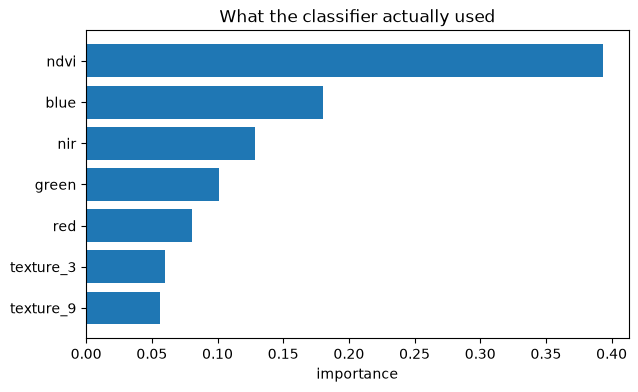

  ndvi         0.393
  blue         0.180
  nir          0.129
  green        0.101
  red          0.081
  texture_3    0.060
  texture_9    0.056


In [8]:
order = np.argsort(rf.feature_importances_)[::-1]

plt.figure(figsize=(7, 4))
plt.barh([FEATURE_NAMES[i] for i in order][::-1],
         rf.feature_importances_[order][::-1])
plt.xlabel("importance")
plt.title("What the classifier actually used")

plt.savefig(config.FIGURES / "03_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

for i in order:
    print(f"  {FEATURE_NAMES[i]:12s} {rf.feature_importances_[i]:.3f}")

In [9]:
import joblib

joblib.dump(rf, config.MODEL_PATH)
print(f"saved to {config.MODEL_PATH}")

saved to C:\Users\Jamie\Developer\nyc-canopy-segmentation\canopy_rf.joblib
